In [4]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

df = pd.read_csv("../data/world_bank_raw.csv")

print("Datos cargados OK")
print(f"Shape: {df.shape}")
print(f"Países: {df['country'].unique()}")
print(f"Años: {df['year'].min()} - {df['year'].max()}")

Datos cargados OK
Shape: (76, 7)
Países: <StringArray>
['Argentina', 'Brazil', 'Germany', 'Mexico']
Length: 4, dtype: str
Años: 2005 - 2023


In [5]:
df_norm = df.copy()

def normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min()) * 100

# Más alto = más riesgo (normalización directa)
df_norm["r_inflation"]    = normalizar(df["inflation"])
df_norm["r_debt"]         = normalizar(df["debt_to_gdp"])
df_norm["r_unemployment"] = normalizar(df["unemployment"])

# Más alto = menos riesgo (normalización invertida)
df_norm["r_gdp"]          = 100 - normalizar(df["gdp_growth"])
df_norm["r_fdi"]          = 100 - normalizar(df["fdi_inflow"])

print("Normalización OK")
print(df_norm[["country", "year", "r_inflation", "r_debt", "r_gdp", "r_fdi", "r_unemployment"]].head(8))

Normalización OK
     country  year  r_inflation     r_debt      r_gdp      r_fdi  \
0  Argentina  2005     7.090771  37.615449  11.771829  45.358699   
1  Argentina  2006     8.065693  29.638959  11.771829  51.987178   
2  Argentina  2007     6.490819  22.334173   7.050143  55.193482   
3  Argentina  2008     6.340832  15.365239  31.385733  44.356925   
4  Argentina  2009     4.615970  16.708648  80.425221  81.008479   
5  Argentina  2010     7.765717   6.717045   1.555448  44.721084   
6  Argentina  2011     7.240759   2.854744  21.815925  60.298748   
7  Argentina  2012     7.390747   4.114190  56.376291  41.471892   

   r_unemployment  
0       66.895353  
1       66.895353  
2       52.186242  
3       46.395902  
4       53.787047  
5       45.270765  
6       40.386023  
7       40.724479  


In [6]:
# Pesos basados en literatura de riesgo-país
WEIGHTS = {
    "r_inflation":    0.35,
    "r_debt":         0.20,
    "r_gdp":          0.20,
    "r_unemployment": 0.15,
    "r_fdi":          0.10,
}

df_norm["risk_index"] = sum(
    df_norm[col] * weight
    for col, weight in WEIGHTS.items()
)

# Redondear a 2 decimales
df_norm["risk_index"] = df_norm["risk_index"].round(2)

print("Índice de riesgo calculado OK")
print(f"\nResumen por país (promedio 2004-2023):")
print(df_norm.groupby("country")["risk_index"].mean().round(2).sort_values(ascending=False))

Índice de riesgo calculado OK

Resumen por país (promedio 2004-2023):
country
Argentina    34.83
Brazil       28.58
Germany      24.58
Mexico       18.06
Name: risk_index, dtype: float64


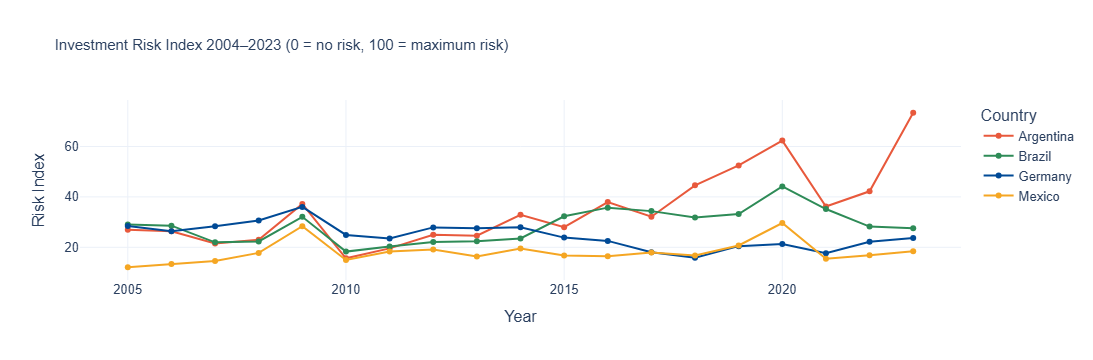

In [7]:
fig = px.line(
    df_norm,
    x="year",
    y="risk_index",
    color="country",
    title="Investment Risk Index 2004–2023 (0 = no risk, 100 = maximum risk)",
    labels={"year": "Year", "risk_index": "Risk Index", "country": "Country"},
    markers=True,
    color_discrete_map={
        "Argentina": "#E8593C",
        "Germany":   "#004A96",
        "Brazil":    "#2E8B57",
        "Mexico":    "#F5A623"
    }
)

fig.update_layout(
    template="plotly_white",
    legend_title="Country",
    font=dict(family="Arial", size=13),
    title_font_size=15,
    hovermode="x unified"
)

fig.show()

In [5]:
output_path = "../data/risk_index.csv"
df_norm.to_csv(output_path, index=False)
print(f"Guardado OK: {output_path}")
print(f"Columnas: {list(df_norm.columns)}")

Guardado OK: ../data/risk_index.csv
Columnas: ['country', 'year', 'debt_to_gdp', 'fdi_inflow', 'gdp_growth', 'inflation', 'unemployment', 'r_inflation', 'r_debt', 'r_unemployment', 'r_gdp', 'r_fdi', 'risk_index']
